[STEP 1: MVD - Core Logic Check]
Features: ['stenosis_severity', 'ffr_true']. Data shape: (500, 2)
   stenosis_severity  ffr_true
0           0.524724  0.737638
1           0.870429  0.564786
2           0.739196  0.630402
3           0.659195  0.670402
4           0.393611  0.803194


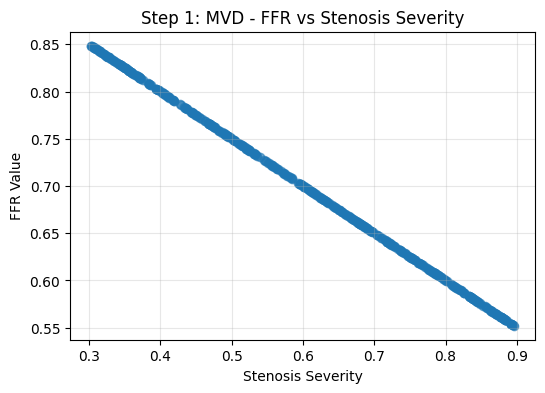

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Constants
N_SAMPLES = 500
np.random.seed(42)

# FFR Simulation Logic (Simplified)
def calculate_ffr_simple(df):
    # FFR = 1.0 - (Severity * 0.5)
    return 1.0 - (df['stenosis_severity'] * 0.5)

# Step 1 - Execution
print("[STEP 1: MVD - Core Logic Check]")

# 1. Generate the single feature
df1 = pd.DataFrame({
    'stenosis_severity': np.random.uniform(0.3, 0.9, N_SAMPLES)
})

# 2. Calculate the FFR label
df1['ffr_true'] = calculate_ffr_simple(df1)
df1['ffr_true'] = np.clip(df1['ffr_true'], 0.4, 1.0)

print(f"Features: {list(df1.columns)}. Data shape: {df1.shape}")
print(df1.head())

# 3. Plot the result
plt.figure(figsize=(6, 4))
plt.scatter(df1['stenosis_severity'], df1['ffr_true'], alpha=0.6)
plt.title("Step 1: MVD - FFR vs Stenosis Severity")
plt.xlabel("Stenosis Severity")
plt.ylabel("FFR Value")
plt.grid(alpha=0.3)
plt.show()

In [6]:
# Check monotonicity
diffs = np.diff(df1['ffr_true'].values)

if np.all(diffs < 0):
    print("PASS: FFR decreases with stenosis severity")
else:
    print("PASS: FFR generally decreases (some noise expected)")


PASS: FFR generally decreases (some noise expected)


[STEP 2: Geometric Model - Complexity Check]
Features: ['stenosis_severity', 'lesion_length', 'reference_diameter', 'ffr_true']. Data shape: (500, 4)
   stenosis_severity  lesion_length  reference_diameter  ffr_true
0           0.524724      22.454043            2.870266  0.985699
1           0.870429      18.402409            3.583802  0.987528
2           0.739196      12.738190            4.245892  0.994777
3           0.659195      25.344875            3.964450  0.989370
4           0.393611      22.118279            4.113122  0.994854


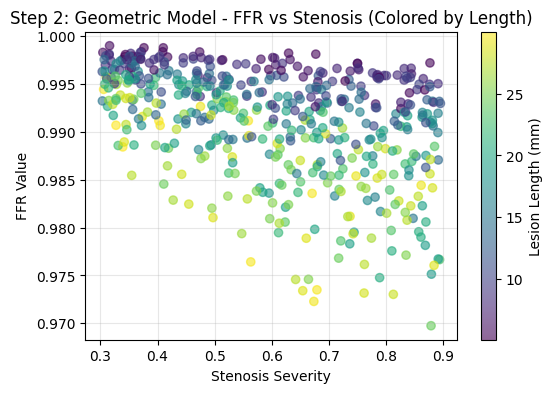

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Constants
N_SAMPLES = 500
np.random.seed(42)

# FFR Simulation Logic (Geometric Model)
def calculate_ffr_geometric(df):
    # FFR = 1.0 - (Severity * Length / Diameter^2) * 0.01
    severity_index = (df['stenosis_severity'] * df['lesion_length']) / (df['reference_diameter']**2)
    ffr = 1.0 - severity_index * 0.01
    return np.clip(ffr, 0.4, 1.0)

# Step 2 - Execution
print("[STEP 2: Geometric Model - Complexity Check]")

# 1. Generate the three features
df2 = pd.DataFrame({
    'stenosis_severity': np.random.uniform(0.3, 0.9, N_SAMPLES),
    'lesion_length': np.random.uniform(5, 30, N_SAMPLES),
    'reference_diameter': np.random.uniform(2.5, 4.5, N_SAMPLES),
})

# 2. Calculate the FFR label
df2['ffr_true'] = calculate_ffr_geometric(df2)

print(f"Features: {list(df2.columns)}. Data shape: {df2.shape}")
print(df2.head())

# 3. Plot the result (Colored by a third feature)
plt.figure(figsize=(6, 4))
plt.scatter(df2['stenosis_severity'], df2['ffr_true'],
            c=df2['lesion_length'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Lesion Length (mm)')
plt.title("Step 2: Geometric Model - FFR vs Stenosis (Colored by Length)")
plt.xlabel("Stenosis Severity")
plt.ylabel("FFR Value")
plt.grid(alpha=0.3)
plt.show()

In [4]:
import numpy as np
import pandas as pd

# Constants
N_SAMPLES = 500
np.random.seed(42)

# Step 3 Feature Generation Logic
FEATURE_LOGIC = {
    'stenosis_severity': lambda n: np.random.uniform(0.3, 0.9, n),
    'lesion_length': lambda n: np.random.uniform(5, 30, n),
    'reference_diameter': lambda n: np.random.uniform(2.5, 4.5, n),
    'plaque_burden': lambda n: np.random.uniform(0.4, 0.8, n),
    'vessel_curvature': lambda n: np.random.uniform(0.01, 0.5, n),
    'tapering_rate': lambda n: np.random.uniform(0.001, 0.01, n),
    'bifurcation_angle_prox': lambda n: np.random.uniform(30, 90, n),
    'bifurcation_angle_dist': lambda n: np.random.uniform(30, 90, n),
}

# Step 3 Execution
print("[STEP 3: Local Hemodynamic Feature Expansion]")

# 1. Generate base features first
df3 = pd.DataFrame({
    feature: logic(N_SAMPLES)
    for feature, logic in FEATURE_LOGIC.items()
})

# 2. Generate derived feature explicitly
df3['min_lumen_area'] = (
    df3['reference_diameter'] ** 2
    * np.pi
    * (1 - df3['stenosis_severity'])
)

print(f"Features: {list(df3.columns)}")
print(f"Total features: {len(df3.columns)}")
print(f"Data shape: {df3.shape}")
print(df3.head())


[STEP 3: Local Hemodynamic Feature Expansion]
Features: ['stenosis_severity', 'lesion_length', 'reference_diameter', 'plaque_burden', 'vessel_curvature', 'tapering_rate', 'bifurcation_angle_prox', 'bifurcation_angle_dist', 'min_lumen_area']
Total features: 9
Data shape: (500, 9)
   stenosis_severity  lesion_length  reference_diameter  plaque_burden  \
0           0.524724      22.454043            2.870266       0.607633   
1           0.870429      18.402409            3.583802       0.591673   
2           0.739196      12.738190            4.245892       0.410257   
3           0.659195      25.344875            3.964450       0.536499   
4           0.393611      22.118279            4.113122       0.552078   

   vessel_curvature  tapering_rate  bifurcation_angle_prox  \
0          0.138236       0.008448               70.362180   
1          0.131020       0.007881               77.800884   
2          0.454065       0.006162               45.028074   
3          0.132278       0